# 06. 산업 데이터 전처리 및 정제 실습

## 학습 목표
1. 산업 현장 데이터(영상/라벨/센서)의 품질 이슈를 식별한다.
2. 정합성 검증, 결측/이상치/중복 처리 파이프라인을 구현한다.
3. 모델 학습 전 사용할 수 있는 **정제 완료 데이터셋**을 만든다.

---

본 노트북은 `PCB Defect` 데이터셋을 기반으로 다음을 실습합니다.
- 이미지-라벨 정합성 검증
- 라벨 품질 정제 (좌표 범위, bbox 이상치)
- 파일명 메타데이터 정규화
- 센서 데이터 결측/이상치 보정
- 정제 리포트 및 저장

In [1]:
from pathlib import Path
import re
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

plt.rcParams["font.family"] = "Malgun Gothic"
plt.rcParams["axes.unicode_minus"] = False

PROJECT_ROOT = Path("..").resolve()
DATA_ROOT = PROJECT_ROOT / "data" / "pcb-defect-dataset" / "pcb-defect-dataset"
OUT_DIR = PROJECT_ROOT / "outputs" / "data_cleaning"
OUT_DIR.mkdir(parents=True, exist_ok=True)

print("PROJECT_ROOT:", PROJECT_ROOT)
print("DATA_ROOT exists:", DATA_ROOT.exists())
print("OUT_DIR:", OUT_DIR)

PROJECT_ROOT: C:\MyCursorLab\10_프로젝트
DATA_ROOT exists: True
OUT_DIR: C:\MyCursorLab\10_프로젝트\outputs\data_cleaning


## 1) 데이터 로드 및 기본 진단

먼저 split별 이미지/라벨 개수와 정합성을 확인합니다.

In [2]:
SPLITS = ["train", "val", "test"]


def split_inventory(split: str) -> dict:
    img_dir = DATA_ROOT / split / "images"
    lbl_dir = DATA_ROOT / split / "labels"

    images = sorted(img_dir.glob("*.jpg"))
    labels = sorted(lbl_dir.glob("*.txt"))

    img_stems = {p.stem for p in images}
    lbl_stems = {p.stem for p in labels}

    return {
        "split": split,
        "num_images": len(images),
        "num_labels": len(labels),
        "matched": len(img_stems & lbl_stems),
        "img_only": len(img_stems - lbl_stems),
        "lbl_only": len(lbl_stems - img_stems),
    }

inventory_df = pd.DataFrame([split_inventory(s) for s in SPLITS])
display(inventory_df)

inventory_df.to_csv(OUT_DIR / "inventory_summary.csv", index=False, encoding="utf-8-sig")

,split,num_images,num_labels,matched,img_only,lbl_only
0,train,8534,8534,6370,2164,2164
1,val,1066,1066,802,264,264
2,test,1068,1068,829,239,239


## 2) 라벨 파싱 및 품질 검증

검증 항목:
- 형식 오류 (토큰 개수 불일치)
- class_id 범위 오류
- 좌표 범위 오류 (0~1)
- bbox 면적 극단값 (너무 작거나 큰 박스)
- 이미지 없는 라벨

In [3]:
VALID_CLASS_IDS = set(range(6))


def parse_label_file(path: Path):
    rows, issues = [], []

    text = path.read_text(encoding="utf-8").strip()
    if not text:
        issues.append({"file": path.name, "issue": "empty_label", "detail": "빈 라벨 파일"})
        return rows, issues

    for line_idx, line in enumerate(text.splitlines(), start=1):
        parts = line.split()
        if len(parts) != 5:
            issues.append({
                "file": path.name,
                "issue": "format_error",
                "detail": f"line {line_idx}: token={len(parts)}"
            })
            continue

        cls, cx, cy, w, h = map(float, parts)
        cls = int(cls)

        rows.append({
            "stem": path.stem,
            "class_id": cls,
            "cx": cx,
            "cy": cy,
            "w": w,
            "h": h,
            "bbox_area": w * h,
        })

        if cls not in VALID_CLASS_IDS:
            issues.append({"file": path.name, "issue": "invalid_class", "detail": f"class={cls}"})
        if not (0 <= cx <= 1 and 0 <= cy <= 1 and 0 <= w <= 1 and 0 <= h <= 1):
            issues.append({"file": path.name, "issue": "coord_out_of_range", "detail": f"{cls} {cx} {cy} {w} {h}"})
        if w * h < 0.0003:
            issues.append({"file": path.name, "issue": "tiny_bbox", "detail": f"area={w*h:.6f}"})
        if w * h > 0.30:
            issues.append({"file": path.name, "issue": "huge_bbox", "detail": f"area={w*h:.6f}"})

    return rows, issues


def build_label_quality_table(splits=None):
    splits = splits or SPLITS
    all_rows, all_issues = [], []

    for split in splits:
        lbl_dir = DATA_ROOT / split / "labels"
        img_stems = {p.stem for p in (DATA_ROOT / split / "images").glob("*.jpg")}

        for lbl_path in lbl_dir.glob("*.txt"):
            rows, issues = parse_label_file(lbl_path)
            for r in rows:
                r["split"] = split
                all_rows.append(r)
            for i in issues:
                i["split"] = split
                all_issues.append(i)

            if lbl_path.stem not in img_stems:
                all_issues.append({
                    "file": lbl_path.name,
                    "issue": "missing_image_for_label",
                    "detail": "동일 stem 이미지 없음",
                    "split": split,
                })

    return pd.DataFrame(all_rows), pd.DataFrame(all_issues)

label_df, issue_df = build_label_quality_table()
print("총 bbox 수:", len(label_df))
print("총 이슈 수:", len(issue_df))

display(issue_df.groupby(["split", "issue"]).size().rename("count").reset_index().sort_values(["split", "count"], ascending=[True, False]))

총 bbox 수: 21664
총 이슈 수: 2667


,split,issue,count
0,test,missing_image_for_label,239
1,train,missing_image_for_label,2164
2,val,missing_image_for_label,264


In [4]:
# 이슈 리포트 저장
if len(issue_df):
    issue_df.to_csv(OUT_DIR / "label_quality_issues.csv", index=False, encoding="utf-8-sig")

label_df.to_csv(OUT_DIR / "label_bbox_table.csv", index=False, encoding="utf-8-sig")
print("저장 완료:")
print("-", OUT_DIR / "label_bbox_table.csv")
print("-", OUT_DIR / "label_quality_issues.csv")

저장 완료:
- C:\MyCursorLab\10_프로젝트\outputs\data_cleaning\label_bbox_table.csv
- C:\MyCursorLab\10_프로젝트\outputs\data_cleaning\label_quality_issues.csv


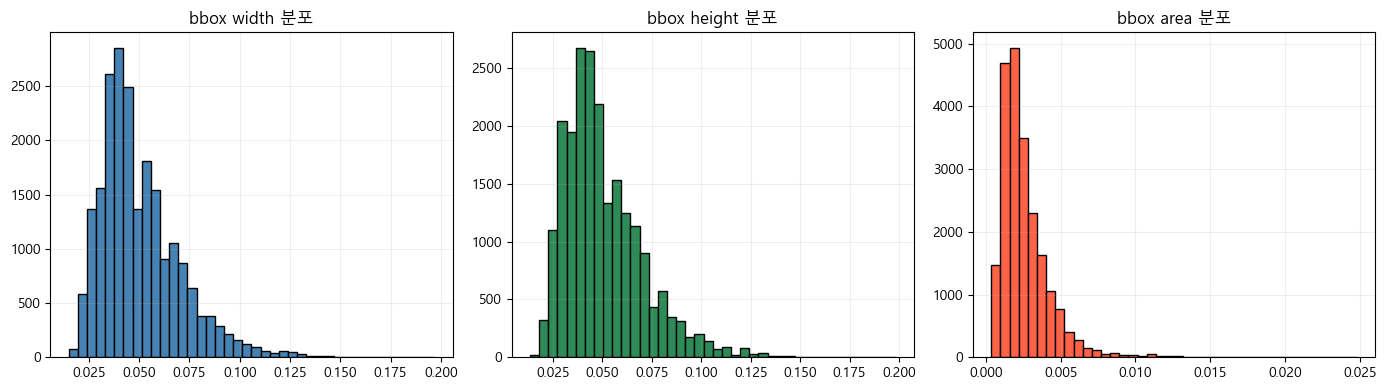

In [5]:
# bbox 분포 확인
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

axes[0].hist(label_df["w"], bins=40, color="steelblue", edgecolor="black")
axes[0].set_title("bbox width 분포")

axes[1].hist(label_df["h"], bins=40, color="seagreen", edgecolor="black")
axes[1].set_title("bbox height 분포")

axes[2].hist(label_df["bbox_area"], bins=40, color="tomato", edgecolor="black")
axes[2].set_title("bbox area 분포")

for ax in axes:
    ax.grid(alpha=0.2)

plt.tight_layout()
plt.show()

## 3) 파일명 메타데이터 정규화

파일명에서 조명/회전/결함명을 파싱해 분석용 메타 컬럼을 만듭니다.

In [6]:
FILENAME_RE = re.compile(
    r"^(?:(l)_)?(?:(rotation_\d+)_)?light_(\d+)_(.+?)_(\d+)_(\d+)_(256|600)$"
)


def parse_stem(stem: str):
    m = FILENAME_RE.match(stem)
    if not m:
        return {
            "stem": stem,
            "parsed": False,
            "flip": None,
            "rotation": None,
            "light": None,
            "defect_name": None,
            "resolution": None,
        }

    flip, rotation, light, defect, board_id, variant, res = m.groups()
    return {
        "stem": stem,
        "parsed": True,
        "flip": bool(flip),
        "rotation": rotation or "none",
        "light": int(light),
        "defect_name": defect,
        "resolution": int(res),
    }

meta_df = label_df[["stem"]].drop_duplicates().copy()
meta_parsed = pd.DataFrame([parse_stem(s) for s in meta_df["stem"]])
meta_df = meta_df.merge(meta_parsed, on="stem", how="left")

print("파싱 성공률:", f"{100*meta_df['parsed'].mean():.2f}%")
display(meta_df.head())

display(meta_df.groupby(["rotation", "resolution"], dropna=False).size().rename("count").reset_index().sort_values("count", ascending=False).head(12))

파싱 성공률: 100.00%


,stem,parsed,flip,rotation,light,defect_name,resolution
0,light_01_missing_hole_01_1_256,True,False,none,1,missing_hole,256
1,light_01_missing_hole_01_2_256,True,False,none,1,missing_hole,256
2,light_01_missing_hole_02_1_256,True,False,none,1,missing_hole,256
3,light_01_missing_hole_03_1_256,True,False,none,1,missing_hole,256
4,light_01_missing_hole_04_1_256,True,False,none,1,missing_hole,256


,rotation,resolution,count
0,none,256,2667
1,none,600,2667
2,rotation_270,600,2667
3,rotation_90,600,2667


## 4) 센서 데이터 전처리·정제 실습 (시뮬레이션)

산업 데이터에서는 결측치/이상치/스파이크가 자주 발생합니다.
아래는 현업에서 자주 쓰는 순서를 실습합니다.

1. 결측치 탐지
2. 이상치 탐지 (IQR 또는 z-score)
3. 보정 (보간/clip/winsorize)
4. 파생 feature 생성

In [7]:
rng = np.random.default_rng(42)
N = 500
t = np.arange(N)

sensor = pd.DataFrame({
    "t": t,
    "lux": 950 + 70*np.sin(2*np.pi*t/120) + rng.normal(0, 18, N),
    "temp": 24 + 0.0015*t + rng.normal(0, 0.12, N),
    "vibration": 0.05 + np.abs(rng.normal(0, 0.01, N)),
})

# 결측치/이상치 주입
missing_idx = rng.choice(N, size=20, replace=False)
outlier_idx = rng.choice(N, size=12, replace=False)

sensor.loc[missing_idx, "lux"] = np.nan
sensor.loc[outlier_idx[:6], "temp"] += 2.5
sensor.loc[outlier_idx[6:], "vibration"] += 0.08

print("원본 결측치 개수")
print(sensor.isna().sum())

display(sensor.head())

원본 결측치 개수
t             0
lux          20
temp          0
vibration     0
dtype: int64


,t,lux,temp,vibration
0,0,955.484907,24.163663,0.050593
1,1,934.943803,24.108922,0.057293
2,2,970.825114,23.916662,0.054145
3,3,977.880577,23.824200,0.056339
4,4,929.435185,23.650257,0.050030


In [8]:
def iqr_clip(series: pd.Series, k: float = 1.5):
    q1, q3 = series.quantile(0.25), series.quantile(0.75)
    iqr = q3 - q1
    lower, upper = q1 - k*iqr, q3 + k*iqr
    return series.clip(lower, upper), lower, upper

clean = sensor.copy()

# 1) 결측치 보간
clean["lux"] = clean["lux"].interpolate(method="linear").bfill().ffill()

# 2) 이상치 클리핑
for col in ["lux", "temp", "vibration"]:
    clean[col], lo, hi = iqr_clip(clean[col], k=1.5)
    print(f"{col:10s} clip range: [{lo:.3f}, {hi:.3f}]")

# 3) 파생 feature
w = 12
for col in ["lux", "temp", "vibration"]:
    clean[f"{col}_roll_mean"] = clean[col].rolling(w, min_periods=1).mean()
    clean[f"{col}_diff1"] = clean[col].diff().fillna(0)

print("\n정제 후 결측치 개수")
print(clean.isna().sum())

display(clean.head())

lux        clip range: [761.427, 1138.971]
temp       clip range: [23.595, 25.147]
vibration  clip range: [0.040, 0.076]

정제 후 결측치 개수
t                      0
lux                    0
temp                   0
vibration              0
lux_roll_mean          0
lux_diff1              0
temp_roll_mean         0
temp_diff1             0
vibration_roll_mean    0
vibration_diff1        0
dtype: int64


,t,lux,temp,vibration,lux_roll_mean,lux_diff1,temp_roll_mean,temp_diff1,vibration_roll_mean,vibration_diff1
0,0,955.484907,24.163663,0.050593,955.484907,0.000000,24.163663,0.000000,0.050593,0.000000
1,1,934.943803,24.108922,0.057293,945.214355,-20.541104,24.136293,-0.054741,0.053943,0.006700
2,2,970.825114,23.916662,0.054145,953.751275,35.881311,24.063083,-0.192260,0.054010,-0.003148
3,3,977.880577,23.824200,0.056339,959.783600,7.055463,24.003362,-0.092463,0.054592,0.002194
4,4,929.435185,23.650257,0.050030,953.713917,-48.445392,23.932741,-0.173943,0.053680,-0.006309


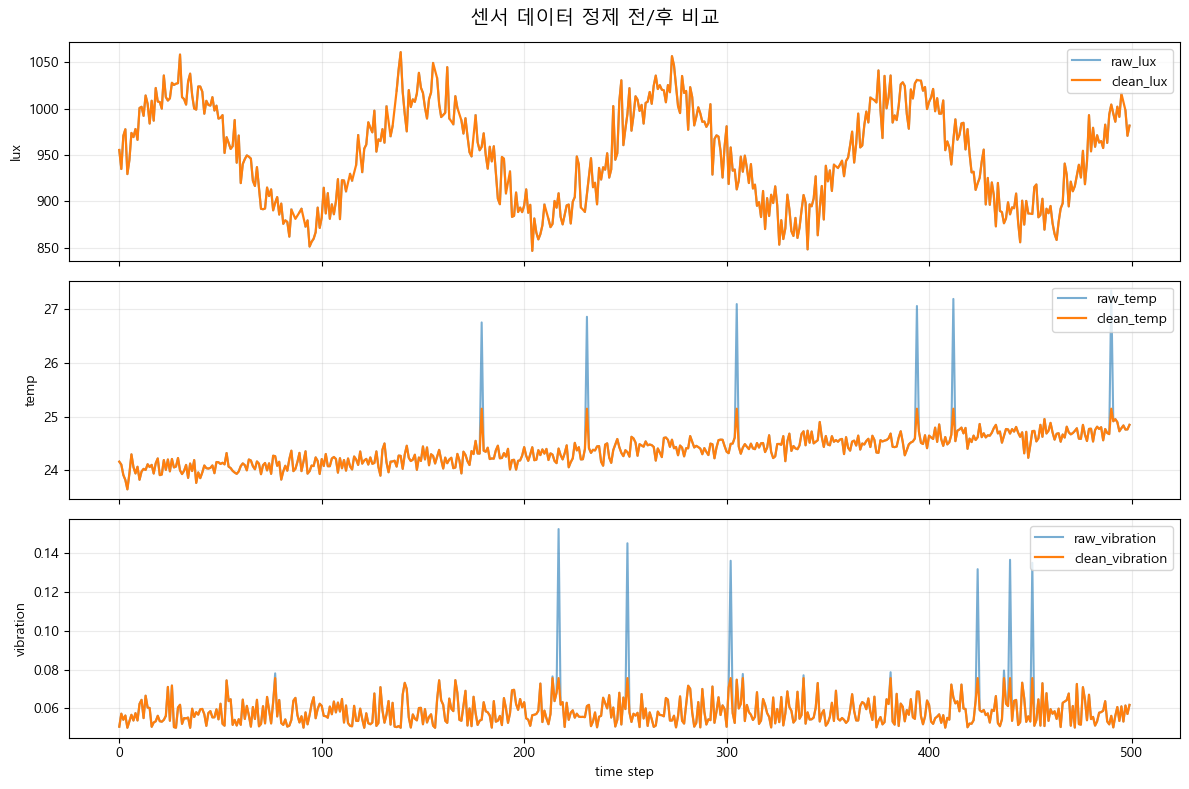

In [9]:
# 정제 전/후 비교 시각화
fig, axes = plt.subplots(3, 1, figsize=(12, 8), sharex=True)
cols = ["lux", "temp", "vibration"]

for i, c in enumerate(cols):
    axes[i].plot(sensor["t"], sensor[c], label=f"raw_{c}", alpha=0.6)
    axes[i].plot(clean["t"], clean[c], label=f"clean_{c}", linewidth=1.6)
    axes[i].set_ylabel(c)
    axes[i].legend(loc="upper right")
    axes[i].grid(alpha=0.25)

axes[-1].set_xlabel("time step")
plt.suptitle("센서 데이터 정제 전/후 비교", fontsize=14)
plt.tight_layout()
plt.show()

In [10]:
# 정제 산출물 저장
clean.to_csv(OUT_DIR / "sensor_cleaned.csv", index=False, encoding="utf-8-sig")
meta_df.to_csv(OUT_DIR / "image_metadata_normalized.csv", index=False, encoding="utf-8-sig")

cleaning_report = {
    "inventory": inventory_df.to_dict(orient="records"),
    "num_bbox_rows": int(len(label_df)),
    "num_label_issues": int(len(issue_df)),
    "num_unique_stems": int(meta_df["stem"].nunique()),
    "filename_parse_success_rate": float(meta_df["parsed"].mean()) if len(meta_df) else 0.0,
    "sensor_rows": int(len(sensor)),
    "sensor_missing_before": sensor.isna().sum().to_dict(),
    "sensor_missing_after": clean.isna().sum().to_dict(),
}

with open(OUT_DIR / "cleaning_report.json", "w", encoding="utf-8") as f:
    json.dump(cleaning_report, f, ensure_ascii=False, indent=2)

print("저장 완료")
print("-", OUT_DIR / "sensor_cleaned.csv")
print("-", OUT_DIR / "image_metadata_normalized.csv")
print("-", OUT_DIR / "cleaning_report.json")

저장 완료
- C:\MyCursorLab\10_프로젝트\outputs\data_cleaning\sensor_cleaned.csv
- C:\MyCursorLab\10_프로젝트\outputs\data_cleaning\image_metadata_normalized.csv
- C:\MyCursorLab\10_프로젝트\outputs\data_cleaning\cleaning_report.json


## 5) 실습 과제

1. bbox 이상치 기준(`tiny/huge`)을 변경해 이슈 개수를 비교하세요.
2. 센서 이상치 처리 방법을 `IQR clip` 대신 `z-score 제거`로 바꿔보세요.
3. `train/val/test`별로 정제 지표를 분리 리포트로 저장하세요.
4. 정제 전/후 데이터로 간단한 baseline 모델 성능 차이를 비교하세요.

---

### 한 줄 정리
산업 데이터 전처리는 단순 정리가 아니라, **현장 오류를 모델 친화적인 구조로 변환하는 과정**입니다.